In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

In [2]:
drive = pd.read_csv('dataset.csv').sample(500000, random_state= 101)
drive.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500000 entries, 879155 to 46460
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   DriverId    500000 non-null  int64  
 1   EventName   500000 non-null  object 
 2   Latitude    500000 non-null  float64
 3   Longitude   500000 non-null  float64
 4   Speed km/h  500000 non-null  float64
 5   ts          500000 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 26.7+ MB


In [3]:
drive.describe()

,DriverId,Latitude,Longitude,Speed km/h
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,43.603432,34.150554,-118.170108,63.178408
std,26.447291,0.449096,0.164704,39.023530
min,0.000000,31.553245,-118.662188,0.000000
25%,19.000000,33.940708,-118.284584,30.000000
50%,45.000000,34.104864,-118.209604,65.000000
75%,65.000000,34.428364,-118.085719,96.000000
max,88.000000,35.248755,-117.442857,178.000000


In [4]:
drive = drive.drop_duplicates()
drive = drive.drop(drive[drive['Speed km/h'] < 5].index)

In [5]:
drive.sample(10)

,DriverId,EventName,Latitude,Longitude,Speed km/h,ts
539165,51,Distance Event,34.606319,-118.045954,105.0,2017-11-04 17:01:02.510
114454,8,Distance Event,33.993499,-118.298850,101.0,2017-11-12 07:49:37.560
89578,7,Timed Event,32.053628,-118.049029,94.0,2017-11-02 10:52:21.750
468956,47,Distance Event,33.868797,-118.382563,111.0,2017-11-05 12:47:34.250
228345,20,Distance Event,34.647624,-117.756220,92.0,2017-11-05 16:20:59.770
125293,10,Timed Event,34.137002,-118.204255,18.0,2017-11-08 18:03:52.600
387116,41,Distance Event,34.486362,-118.113466,37.0,2017-11-02 08:48:13.920
476370,47,Distance Event,33.926484,-118.354094,105.0,2017-11-09 14:11:39.080
65247,5,Distance Event,34.290133,-118.199058,90.0,2017-11-07 11:07:07.310
832356,84,Distance Event,34.126194,-118.282601,70.0,2017-11-02 20:37:32.250


In [6]:
drive.EventName.value_counts()

Distance Event                       375381
Timed Event                           47223
Harsh Acceleration                     8942
System Event                           3256
Harsh Braking                          3207
Reached max speed                      3016
Out of max speed                       1394
Network Event                          1341
Harsh Turn (motion based)              1271
Harsh Braking (motion based)            729
Engine started                          662
Engine turned off                       516
Harsh Acceleration (motion based)       452
Harsh Turn Right (motion based)         444
Harsh Turn Left (motion based)          434
Name: EventName, dtype: int64

In [7]:
drp = ['System Event', 'Network Event','Engine turned off', 'Engine started','Distance Event']
rest = list(set(drive.EventName.unique()).difference(set(drp)))
make = drive[drive.EventName.isin(rest)]

In [8]:
make = make.replace({'EventName': {'Harsh Acceleration (motion based)':'Harsh Acceleration',
                       'Harsh Braking (motion based)':'Harsh Braking',
                        'Harsh Acceleration (motion based)':'Harsh Acceleration',
                        'Harsh Turn Left (motion based)':'Harsh Turn',
                        'Harsh Turn Right (motion based)':'Harsh Turn',
                        'Harsh Turn (motion based)':'Harsh Turn',
                        'Reached max speed': 'Beyond max speed',
                        'Out of max speed':'Beyond max speed'}})

make.EventName.value_counts()

Timed Event           47223
Harsh Acceleration     9394
Beyond max speed       4410
Harsh Braking          3936
Harsh Turn             2149
Name: EventName, dtype: int64

In [9]:
make.columns, make.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67112 entries, 879155 to 557928
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DriverId    67112 non-null  int64  
 1   EventName   67112 non-null  object 
 2   Latitude    67112 non-null  float64
 3   Longitude   67112 non-null  float64
 4   Speed km/h  67112 non-null  float64
 5   ts          67112 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 3.6+ MB


(Index(['DriverId', 'EventName', 'Latitude', 'Longitude', 'Speed km/h', 'ts'], dtype='object'),
 None)

In [10]:
# Days of the Week
import datetime
make.ts = pd.to_datetime(make.ts) #.strftime('%d/%m/%Y %H:%M')
make['Days'] =  [t.date().strftime('%A') for t in make.ts] 
# Visibility
make['visiblity'] = ['Light'if i.time().hour < 20 and i.time().hour > 6 else 'Dark'for i in make.ts]
# Aggressive Driving
crz = ['Harsh Acceleration', 'Harsh Braking', 'Harsh Turn', 'Beyond max speed']
make['agg_drv'] = [1 if i in crz else 0 for i in make.EventName]
# Overspeed
# Speed threshold is set at 80 km/h
make['overspeed'] = [1 if make.iloc[i]['Speed km/h'] > 80 else 1 if make.iloc[i]['EventName']=='Harsh Turn' 
                        and make.iloc[i]['Speed km/h'] > 40 else 0 for i in range(len(make))]
# Fatigue Driving
make['fatigue'] = rd.choices(['Yes', 'No'], weights=[10,30], k=len(make)) # Self generated


# Possible collision distance
# This is a subraction of stopping distance from car distance:
# Taking reaction time to be 0.75s for normal and 1.5 for fatigued, road coef to asphalt,
# car distance to 3s
make['col_dist'] = [round((make.iloc[i]['Speed km/h'] *3)/3.6 - ((make.iloc[i]['Speed km/h'] * 1.5)/3.6 + make.iloc[i]['Speed km/h']**2/(250*0.8)), 2)  if make.iloc[i]['fatigue']=='Yes' 
else round((make.iloc[i]['Speed km/h']*3)/3.6 - ((make.iloc[i]['Speed km/h'] * 0.75)/3.6 + make.iloc[i]['Speed km/h']**2/(250*0.8)), 2) for i in range(len(make))]

In [11]:
make.head(10)

,DriverId,EventName,Latitude,Longitude,Speed km/h,ts,Days,visiblity,agg_drv,overspeed,fatigue,col_dist
879155,87,Timed Event,34.124660,-118.130796,23.0,2017-11-16 08:49:28.520,Thursday,Light,0,0,No,11.73
533839,51,Harsh Acceleration,33.928296,-118.083349,49.0,2017-11-01 19:18:46.780,Wednesday,Light,1,0,No,18.62
6535,0,Timed Event,34.067303,-118.261615,64.0,2017-11-07 14:45:03.060,Tuesday,Light,0,0,Yes,6.19
749935,76,Timed Event,34.136694,-118.238141,18.0,2017-11-06 09:22:40.670,Monday,Light,0,0,No,9.63
176417,15,Timed Event,34.792958,-118.051337,51.0,2017-11-16 19:39:04.090,Thursday,Light,0,0,No,18.87
657730,63,Timed Event,34.002073,-118.295474,67.0,2017-11-06 07:52:10.020,Monday,Light,0,0,No,19.43
738843,75,Harsh Acceleration,33.970864,-118.311289,70.0,2017-11-13 18:37:23.750,Monday,Light,1,0,No,19.25
508104,49,Timed Event,34.039634,-118.335961,16.0,2017-11-08 10:48:12.930,Wednesday,Light,0,0,No,8.72
598785,56,Timed Event,34.134110,-118.222145,73.0,2017-11-02 17:40:49.470,Thursday,Light,0,0,No,18.98
728362,73,Harsh Braking,34.554256,-117.736918,42.0,2017-11-17 06:53:37.570,Friday,Dark,1,0,No,17.43


In [12]:
make.DriverId.unique(), make.DriverId.nunique()

(array([87, 51,  0, 76, 15, 63, 75, 49, 56, 73, 65, 58, 18, 81, 33, 46, 41,
        47, 39, 52, 85, 11, 10,  8, 12, 24, 20, 62,  5, 25, 48, 45, 31, 27,
         1, 44, 77, 70, 61, 82, 22, 40,  7, 14, 60, 59, 78, 68, 54, 84, 23,
        36, 88, 72, 16,  2, 74, 57,  9, 17, 28, 30, 67,  4, 35, 13, 69, 37,
        55, 42, 21, 86,  6, 26, 53, 80, 32, 79, 19,  3, 50, 29, 38, 83, 66,
        43, 71]),
 87)

In [13]:
make = make.drop(['DriverId', 'Longitude', 'Latitude', 'ts'], axis=1)
make.corr() 

,Speed km/h,agg_drv,overspeed,col_dist
Speed km/h,1.000000,0.202067,0.805663,-0.230321
agg_drv,0.202067,1.000000,0.071198,0.081639
overspeed,0.805663,0.071198,1.000000,-0.387904
col_dist,-0.230321,0.081639,-0.387904,1.000000


In [14]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,10

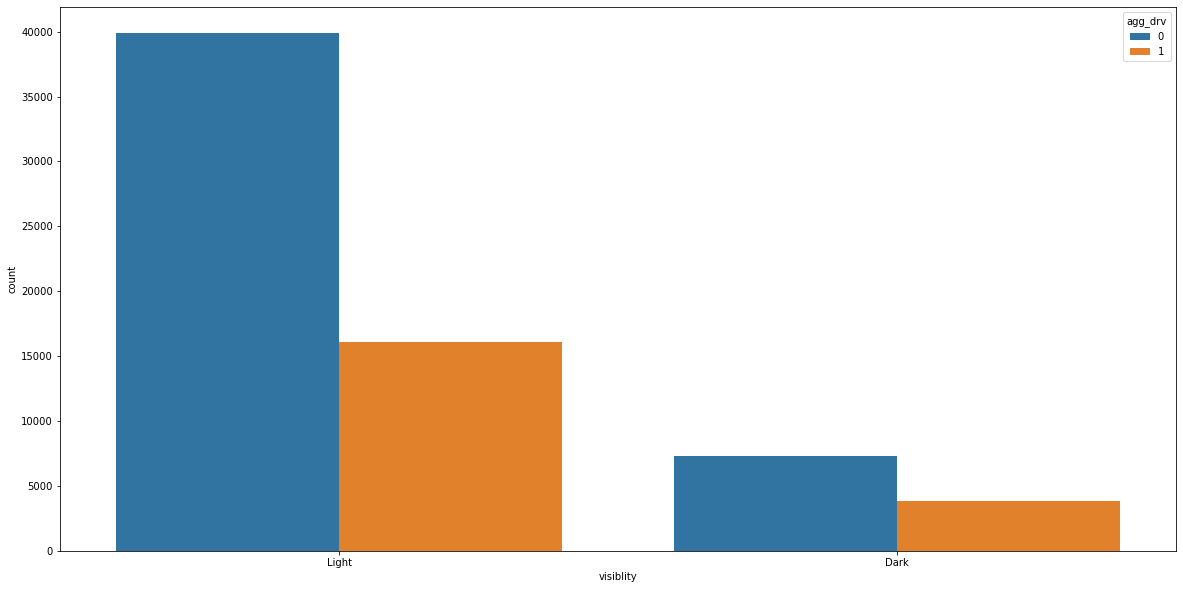

In [15]:
sns.countplot(x= 'visiblity', data = make, hue ='agg_drv')

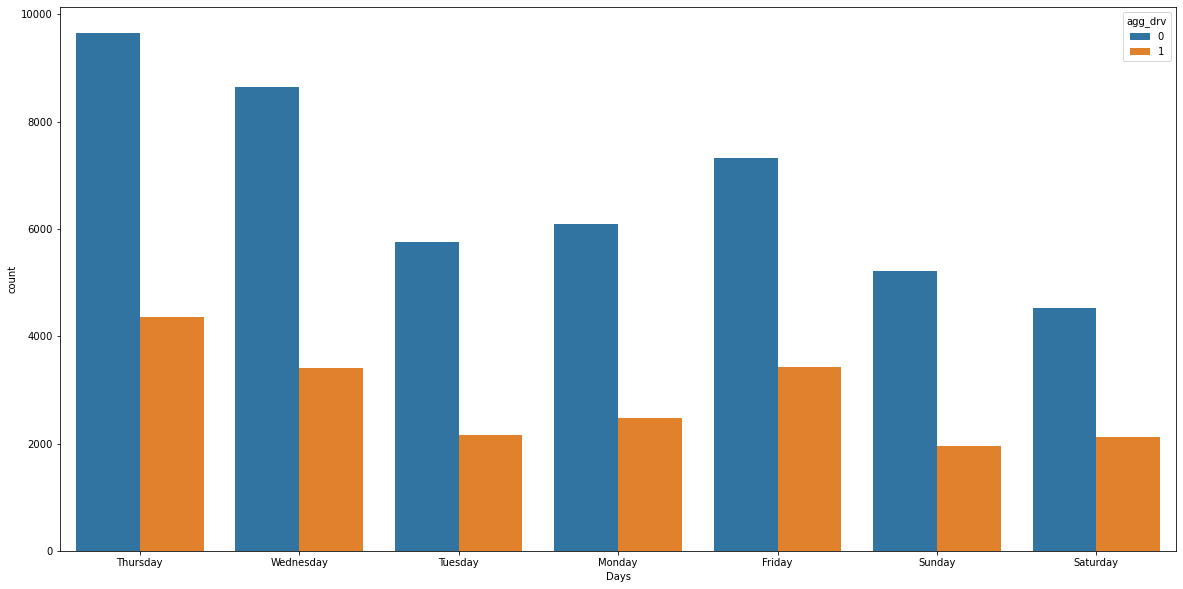

In [16]:
sns.countplot(x= 'Days', data = make, hue ='agg_drv')

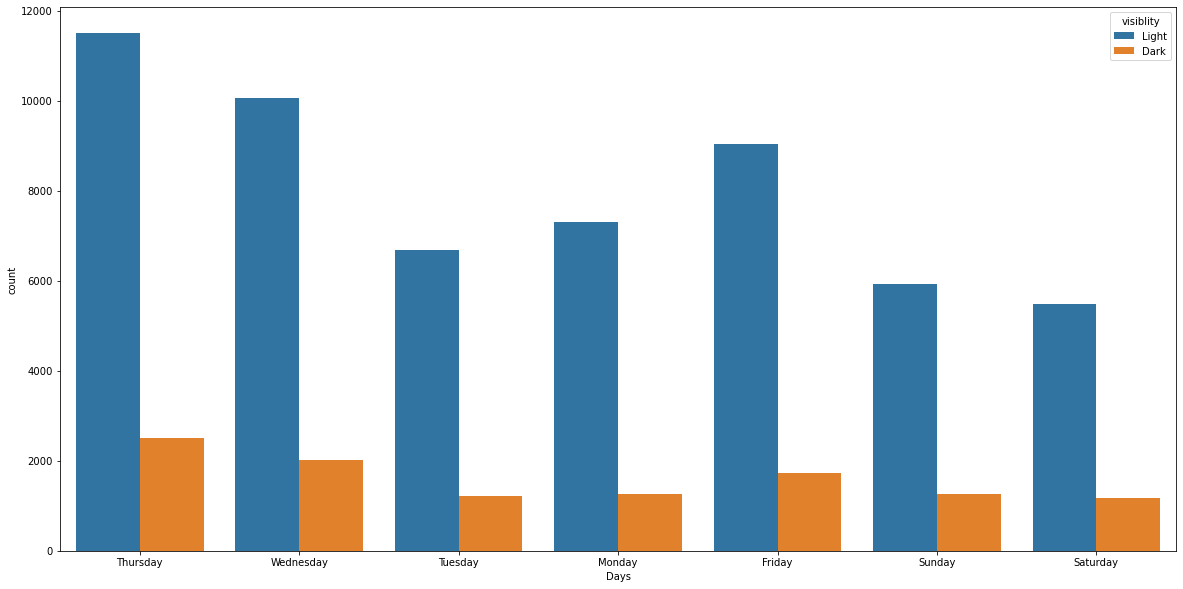

In [17]:
sns.countplot(x= 'Days', data = make, hue ='visiblity')

In [18]:
make.fatigue.value_counts()

No     50320
Yes    16792
Name: fatigue, dtype: int64

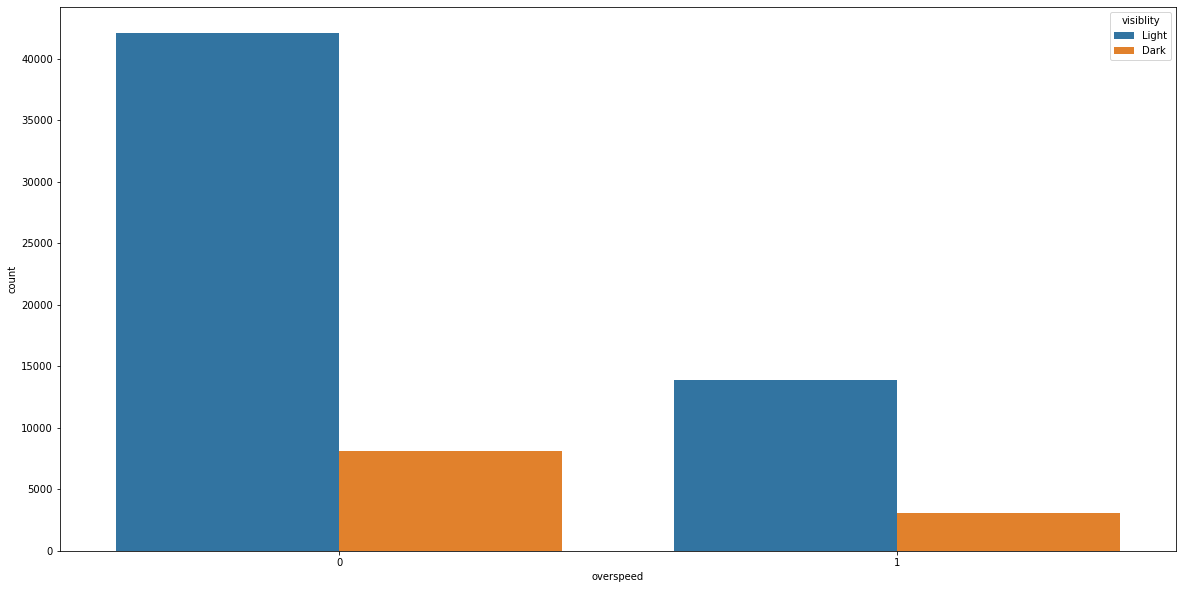

In [19]:
sns.countplot(x= 'overspeed', data = make, hue ='visiblity')

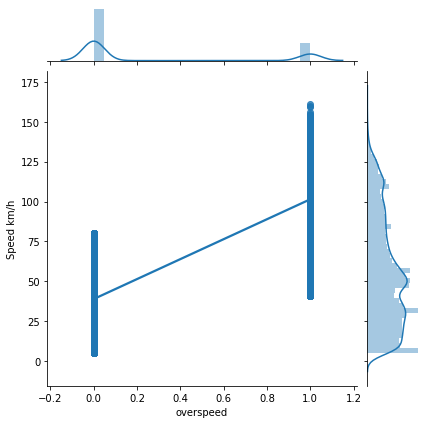

In [20]:
sns.jointplot(x = "overspeed", y = "Speed km/h", data= make, kind='reg')

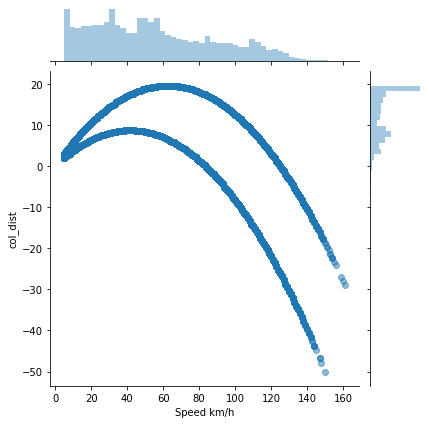

In [21]:
sns.jointplot(y= "col_dist", x = "Speed km/h", data= make, alpha =0.5)

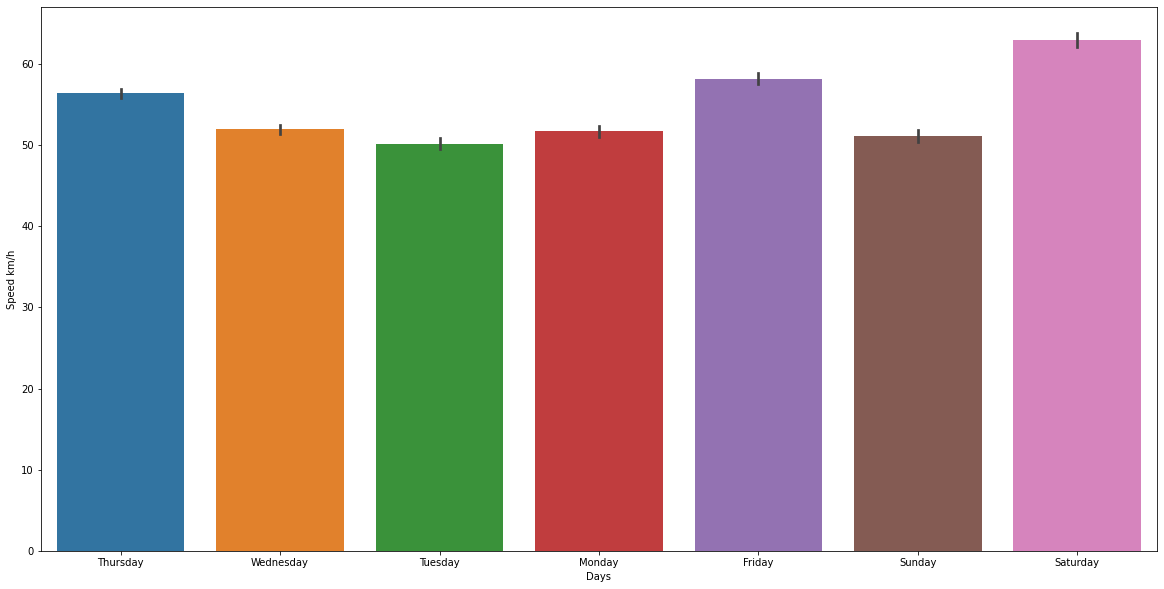

In [22]:
sns.barplot(x = 'Days', y='Speed km/h', data =make)

/home/jubriel/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:369: UserWarning: Default bandwidth for data is 0; skipping density estimation.
  warnings.warn(msg, UserWarning)


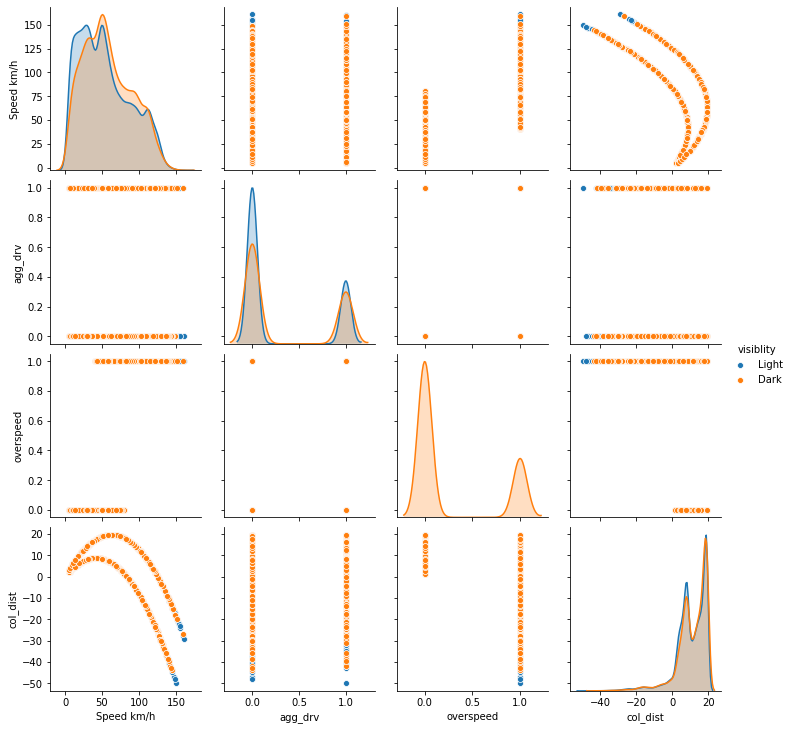

In [23]:
sns.pairplot(make, hue='visiblity')

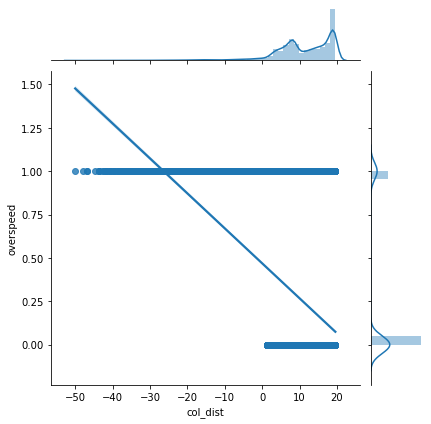

In [24]:
sns.jointplot(x = "col_dist", y = "overspeed", data= make, kind='reg')

In [25]:
maked = make.copy()

In [26]:
make.EventName.value_counts()

Timed Event           47223
Harsh Acceleration     9394
Beyond max speed       4410
Harsh Braking          3936
Harsh Turn             2149
Name: EventName, dtype: int64

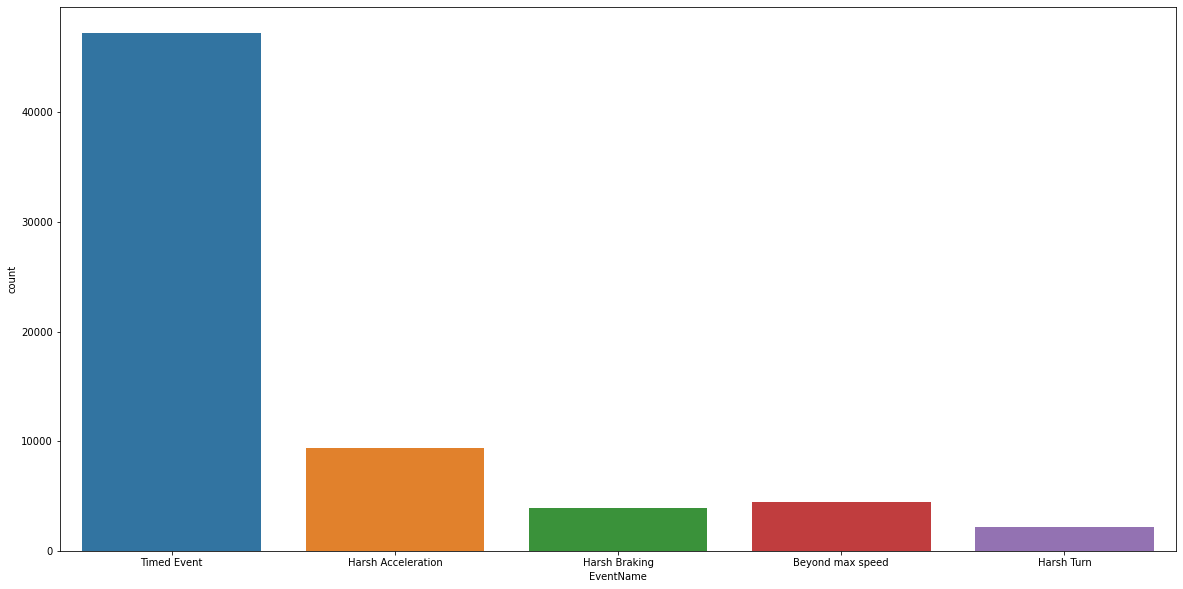

In [27]:
sns.countplot(data = make, x='EventName')

In [28]:
make.sample(20)

,EventName,Speed km/h,Days,visiblity,agg_drv,overspeed,fatigue,col_dist
670259,Beyond max speed,124.0,Monday,Light,1,1,Yes,-25.21
116757,Harsh Acceleration,64.0,Wednesday,Light,1,0,No,19.52
674286,Timed Event,96.0,Thursday,Light,0,1,Yes,-6.08
26512,Timed Event,17.0,Tuesday,Light,0,0,Yes,5.64
528025,Timed Event,11.0,Monday,Light,0,0,Yes,3.98
382314,Timed Event,31.0,Wednesday,Light,0,0,No,14.57
540874,Beyond max speed,100.0,Sunday,Light,1,1,No,12.50
314041,Timed Event,63.0,Saturday,Dark,0,0,No,19.53
86269,Timed Event,123.0,Saturday,Light,0,1,No,1.23
302625,Timed Event,26.0,Tuesday,Light,0,0,No,12.87


In [29]:
# make['Decision'] = ['Guilty' if (make.iloc[i]['overspeed']==1 and make.iloc[i]['fatigue']=='Yes') or 
#                             (make.iloc[i]['agg_drv']=='1' and make.iloc[i]['fatigue']=='Yes') or 
#                             (make.iloc[i]['col_dist'] < 1 and make.iloc[i]['fatigue']=='Yes') 
#                             else 'Guilty' if (make.iloc[i]['overspeed']==1 and make.iloc[i]['agg_drv']=='Yes') or
#                             (make.iloc[i]['col_dist'] < 1 and make.iloc[i]['overspeed']==1)
#                             else 'Innocent' for i in range(len(make))]


In [30]:
# mak = make.copy()
# mak.visiblity = make.visiblity.map({'Light':0, 'Dark':1})
# mak.fatigue = make.fatigue.map({'Yes':1,'No':0})
# mak['col_distd'] = [1 if i < 1 else 0 for i in make.col_dist]
# mak['Decision'] = [round((0.4 * mak.iloc[i]['Speed km/h'] + 0.01 * mak.iloc[i]['visiblity'] + 0.1*mak.iloc[i]['agg_drv']
#                     + 0.4*mak.iloc[i]['fatigue'] + 0.3*mak.iloc[i]['overspeed'] - 0.08*mak.iloc[i]['col_distd'])/100,2)
#                     for i in range(len(mak))]
# mak['Decisiond'] = [round((mak.iloc[i]['visiblity'] + mak.iloc[i]['agg_drv']
#                     + mak.iloc[i]['fatigue'] +  mak.iloc[i]['overspeed'] + mak.iloc[i]['col_distd'])/5,2)
#                     for i in range(len(mak))]


In [31]:
make.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67112 entries, 879155 to 557928
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EventName   67112 non-null  object 
 1   Speed km/h  67112 non-null  float64
 2   Days        67112 non-null  object 
 3   visiblity   67112 non-null  object 
 4   agg_drv     67112 non-null  int64  
 5   overspeed   67112 non-null  int64  
 6   fatigue     67112 non-null  object 
 7   col_dist    67112 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 7.1+ MB


In [32]:
# Importing packages
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
# from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier 

In [33]:
make.skew()

Speed km/h    0.500961
agg_drv       0.891928
overspeed     1.139386
col_dist     -1.693255
dtype: float64

In [34]:
# stroke = stroke.drop('id' , axis =1)
train,test = train_test_split(make, test_size = 0.3, random_state = 101)

import category_encoders as ce
encode = ce.BinaryEncoder(cols= ['EventName', 'visiblity', 'Days','fatigue'])
train = encode.fit_transform(train)
test = encode.transform(test)

In [35]:
sc = StandardScaler()
train = sc.fit_transform(train)
test = sc.transform(test)

In [36]:
from sklearn.decomposition import PCA
pca = PCA(3)
new = pca.fit_transform(train)
print(new.shape)
new = pd.DataFrame(new)
new.head()


(46978, 3)


,0,1,2
0,0.470552,2.433530,0.023654
1,0.082608,2.909505,0.045379
2,-1.502971,0.215768,-0.618760
3,0.410885,-2.482230,-0.613987
4,-0.745779,-1.706295,-0.437401


In [37]:
new.skew()

0    1.433111
1    0.147546
2    1.548911
dtype: float64

In [38]:
from sklearn.cluster import DBSCAN, KMeans
# clt = DBSCAN(eps=3, min_samples=2).fit(new)
clt = KMeans(n_clusters=2, random_state=0).fit(new)
new['Decision'] = clt.labels_

In [39]:
sns.scatterplot(y= 0, x = , data= new, alpha =0.5, hue = 'Decision')

SyntaxError: invalid syntax (<ipython-input-39-cdbd84cfaa71>, line 1)

In [ ]:
# Finding the BaseLine perfomance of the various models

# prepare models
models = []

# Adding algorthms
models.append(('sgd', SGDClassifier()))
models.append(('LR', LogisticRegression()))
# models.append(('knr', KNeighborsClassifier()))
models.append(('rfr', RandomForestClassifier()))
models.append(('xg', XGBClassifier(objective ='reg:squarederror')))
# evaluate -cross validation- each model in turn
results = []
names = []
scoring =['accuracy', 'f1']
for name, model in models:
	kfold = KFold(n_splits=10)
	cv_results = cross_validate(model, train_X, train_y, cv=kfold, scoring=scoring, return_train_score=True)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results['train_accuracy'].mean(), cv_results['test_f1'].mean())
	print(msg)


sgd: 0.997051 (0.989313)
LR: 0.999711 (0.998877)
rfr: 1.000000 (1.000000)
xg: 1.000000 (1.000000)


In [ ]:
wrk = pd.read_csv('Work.csv').drop(['EventName', 'Decision','col_distd'], axis=1)
wrk.columns

Index(['Speed km/h', 'Days', 'visiblity', 'agg_drv', 'overspeed', 'fatigue',
       'col_dist'],
      dtype='object')

In [ ]:
import category_encoders as ce
encode = ce.BinaryEncoder(cols= ['visiblity', 'Days','fatigue'])
wrk = encode.fit_transform(wrk)

sc = StandardScaler()
wrkd = sc.fit_transform(wrk)

from sklearn.cluster import DBSCAN
clust = DBSCAN(eps=3, min_samples=2).fit_predict(wrkd)
wrk['D'] = clust.labels_

: 

: 